# Road Accident Severity Prediction Using Machine Learning

## Problem Statement

#### Predict the severity of a road accident based on factors such as:
##### Weather Conditions
##### Road Surface Conditions
##### Speed Limit
##### Number of Vehicles
##### Light Conditions
##### Urban/Rural Area
##### Vehicle Type

In [1]:
# Load Cleaned Dataset

import pandas as pd

df = pd.read_csv("G:\project\Thiranex\Road_Accident_Analysis\data\Cleaned_Road_Accident_Data.csv")

df.head()

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
C:\Users\BALRAM MANDAL\AppData\Local\Temp\ipykernel_14436\4070306962.py:5: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv("G:\project\Thiranex\Road_Accident_Analysis\data\Cleaned_Road_Accident_Data.csv")


,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,...,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Year,Month,Day,Hour,Casualty_Per_Vehicle
0,200901BS70001,2021-01-01,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,-0.201349,...,30,1900-01-01 15:11:00,Urban,Fine no high winds,Car,2021.0,1.0,1.0,15,0.5
1,200901BS70002,2021-05-01,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,-0.199248,...,30,1900-01-01 10:59:00,Urban,Fine no high winds,Taxi/Private hire car,2021.0,5.0,1.0,10,5.5
2,200901BS70003,2021-04-01,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,-0.179599,...,30,1900-01-01 14:19:00,Urban,Fine no high winds,Taxi/Private hire car,2021.0,4.0,1.0,14,0.5
3,200901BS70004,2021-05-01,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,-0.203110,...,30,1900-01-01 08:10:00,Urban,Other,Motorcycle over 500cc,2021.0,5.0,1.0,8,0.5
4,200901BS70005,2021-06-01,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,-0.173445,...,30,1900-01-01 17:25:00,Urban,Fine no high winds,Car,2021.0,6.0,1.0,17,0.5


In [2]:
# Select Features

features = [
    'Day_of_Week',
    'Junction_Control',
    'Junction_Detail',
    'Light_Conditions',
    'Road_Surface_Conditions',
    'Road_Type',
    'Speed_limit',
    'Urban_or_Rural_Area',
    'Weather_Conditions',
    'Vehicle_Type',
    'Number_of_Casualties',
    'Number_of_Vehicles'
]

target = 'Accident_Severity'

In [3]:
# Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [4]:
# Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Train Decision Tree

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# Predict decision tree

y_pred_dt = dt.predict(X_test)

In [ ]:
# Evaluate decision tree Model

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

Decision Tree Accuracy: 0.81


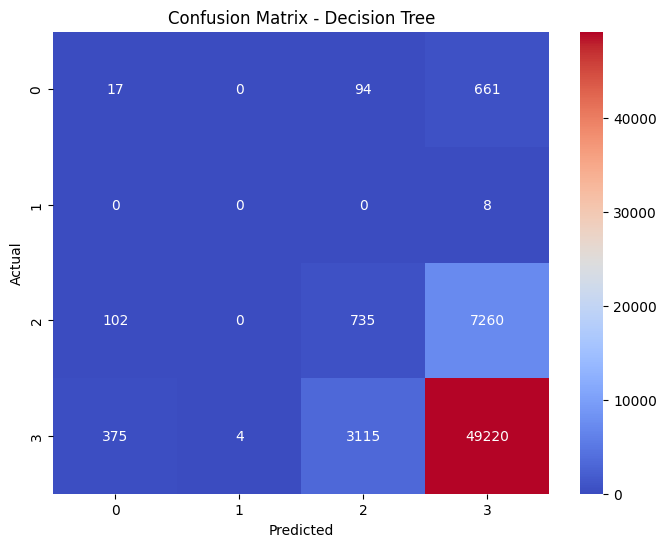

In [10]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [11]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# Predict Random Forest

y_pred_rf = rf.predict(X_test)

In [13]:
# Accuracy Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")

Random Forest Accuracy: 0.84


In [14]:
# Classification Report

from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred_rf)
print("Classification Report - Random Forest:\n", report)

Classification Report - Random Forest:
               precision    recall  f1-score   support

           0       0.03      0.00      0.01       772
           1       0.00      0.00      0.00         8
           2       0.22      0.04      0.07      8097
           3       0.86      0.98      0.91     52714

    accuracy                           0.84     61591
   macro avg       0.28      0.26      0.25     61591
weighted avg       0.76      0.84      0.79     61591



In [15]:
# Feature Importance

importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

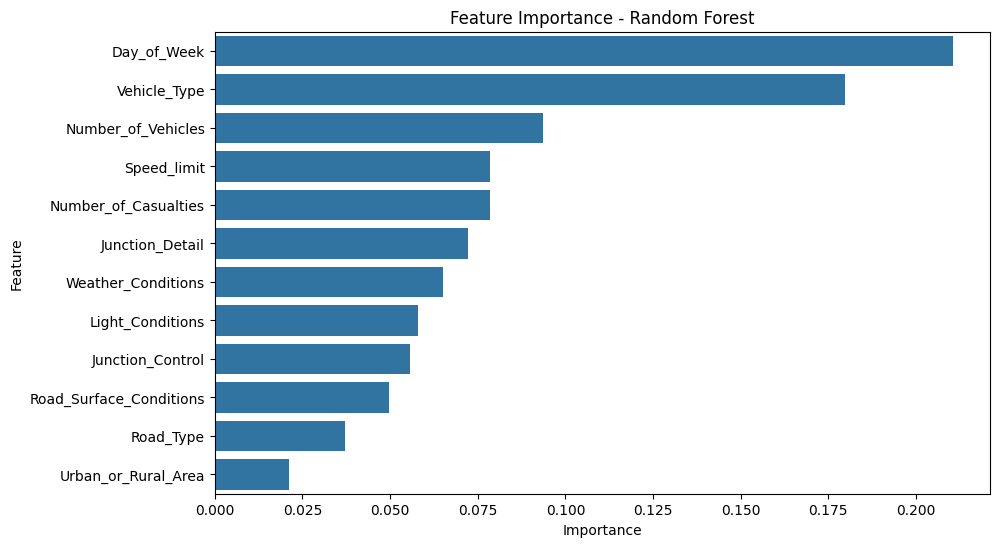

In [16]:
# Plot Feature Importance

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()